# Example 3.5: Auto-spectral density

In this example, we will compute the auto spectral density from an auto correlation function in three different ways.

## Auto correlation function

We will consider the following function:

$$ R(\tau)= \sigma^2 \exp(-\dfrac{\tau^2}{2L^2}) \cos(\bar{\omega} \tau)$$

where $\sigma=10$, $L=2$, and $\bar{\omega}=6$. Let's start by plotting this function.


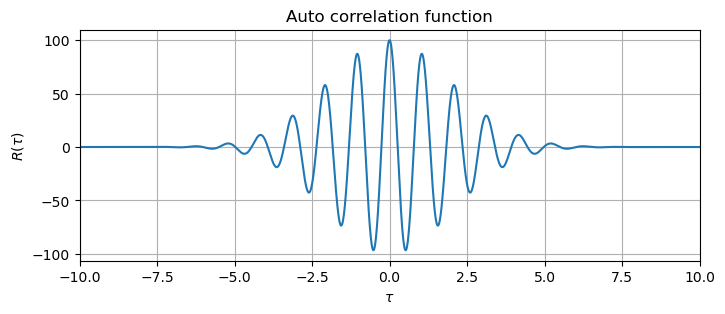

In [1]:
import numpy as np
from matplotlib import pyplot as plt

# Parameters
sigma=10.0
L=2.0
omega_bar=6.0

# Generate lag axis
tau_min = -10.0
tau_max = 10.0
N = 20_000 # Number of lag samples
dtau = (tau_max - tau_min) / N
tau = tau_min + np.arange(N) * dtau # Include tau_min, zero, and exclude tau_max

# Define the auto correlation 
R = sigma**2*np.exp(-tau**2 / (2 * L**2))*np.cos(omega_bar*tau)

# Plot
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tau, R)
ax.set_xlim(-10,10)
ax.set_xlabel(r'$\tau$')
ax.set_ylabel(r'$R(\tau)$')
ax.set_title('Auto correlation function')
ax.grid(True)


The figure shows that the process has a cyclic, fading correlation. This indicates that this stochastic process is dominated by a frequency, which unsurprisingly is related to the parameter $\bar{\omega}$. This will be better illustrated from the spectral density.

## Method 1: Analytical Fourier transform

The spectral density is defined as:

$$
S(\omega)=
\dfrac{1}{2 \pi}
\int_{-\infty}^{\infty}
R(\tau) \exp({-i \omega \tau}) \: \text{d} \tau
$$

We have to solve the integral. Not all functions can be transformed to the frequency domain analytically, but functions containing $\exp()$ and $\cos()$ are usually easy to integrate. This function has probably been considered by many before us. Asking a language model can likely help us.

<p align="center">    <img src="figures/FT_chatgpt1.jpg" alt="Image 1" style="width: 49%; display: inline-block; border: 1px solid black">
    <img src="figures/FT_chatgpt2.jpg" alt="Image 2" style="width: 50%; display: inline-block; border: 1px solid black">
>
<p>h
The solution looks correct, but it has "forgotten" the $\dfrac{1}{2\pi}$ factor in front of the FT integral in Step 2. This is because the FT can be defined (scaled) in several ways. However, we always use the scaling $\dfrac{1}{2\pi}$. Therefore, the spectral density is:

$$
S(\omega)=
\sigma^2
\dfrac{1}{2\pi}
\sqrt{\frac{\pi L^2}{2}} \left[ \exp \Big({-\frac{L^2(\bar{\omega} - \omega)^2}{2}} \Big) + \exp \Big( {-\frac{L^2(\bar{\omega} + \omega)^2}{2}} \Big) \right]
$$

As a check, the area under the two-sided spectral density should equal the variance $R(0)=\sigma^2=100$.



Integral of S(omega): 100.000


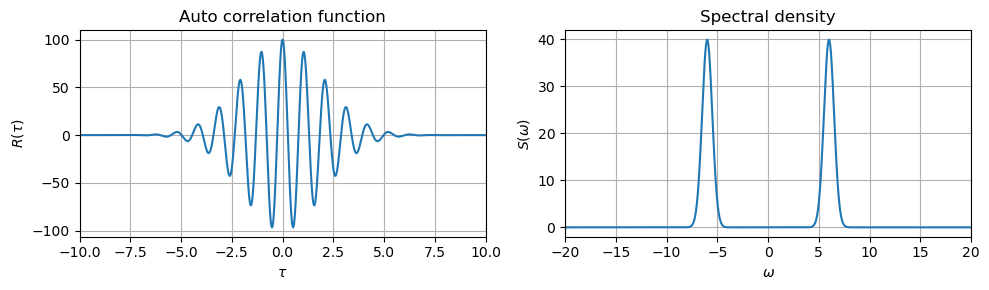

In [2]:
# Frequency axis
domega=0.02
omega=np.arange(-20,20+domega,domega)

# Analytical solution
S=sigma**2/(2*np.pi)*np.sqrt(np.pi*L**2/2)*( np.exp(-L**2*(omega_bar-omega)**2/2) + np.exp(-L**2*(omega_bar+omega)**2/2) )

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Plot ACF
axes[0].plot(tau,R)
axes[0].set_xlim(-10,10)
axes[0].set_xlabel(r'$\tau$')
axes[0].set_ylabel(r'$R(\tau)$')
axes[0].set_title('Auto correlation function')
axes[0].grid(True)

# Plot PSD
axes[1].plot(omega,S, label='PSD')
axes[1].set_xlim(-20,20)
axes[1].set_xlabel(r'$\omega$')
axes[1].set_ylabel(r'$S(\omega)$')
axes[1].set_title('Spectral density')
axes[1].grid(True)

plt.tight_layout()

variance = np.trapezoid(S,omega)
print(f'Integral of S(omega): {variance:.3f}')

## Method 2: Fourier transform by numerical integration

The spectral density is defined as:
$$
S(\omega)=
\dfrac{1}{2 \pi}
\int_{-\infty}^{\infty}
R(\tau) \exp({-i \omega \tau}) \: \text{d} \tau
$$

We can use the trapezoidal rule to calculate the integral. The integral must then be calculated for each $\omega$.

Maximum imaginary part: 5.66e-08


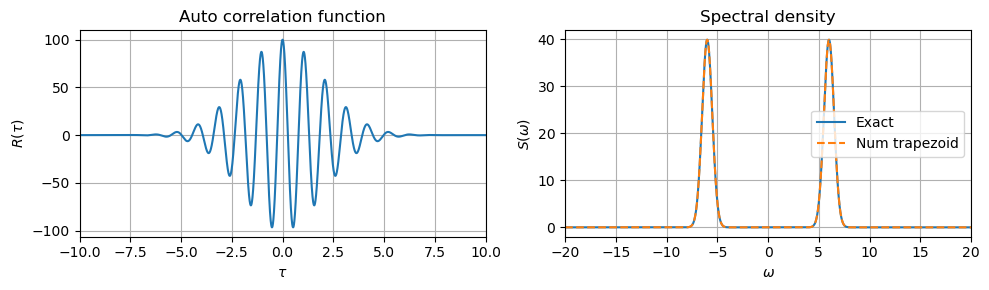

In [3]:
# Numerical integration by trapezoidal rule

# Solve integral for each omega
S_num = np.zeros(omega.shape[0],dtype=complex)
for k in range(omega.shape[0]):
    S_num[k] = 1/(2*np.pi)*np.trapezoid(R*np.exp(-1j*omega[k]*tau),tau)

print(f'Maximum imaginary part: {np.max(np.abs(S_num.imag)):.2e}')

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Plot auto correlation
axes[0].plot(tau,R)
axes[0].set_xlim(-10,10)
axes[0].set_xlabel(r'$\tau$')
axes[0].set_ylabel(r'$R(\tau)$')
axes[0].set_title('Auto correlation function')
axes[0].grid(True)

# Plot PSD
axes[1].plot(omega,S, label='Exact')
axes[1].plot(omega,np.real(S_num), linestyle='--',label='Num trapezoid')
axes[1].set_xlim(-20,20)
axes[1].set_xlabel(r'$\omega$')
axes[1].set_ylabel(r'$S(\omega)$')
axes[1].set_title('Spectral density')
axes[1].legend()
axes[1].grid()

plt.tight_layout()


## Method 3: FFT

The spectral density is defined as:

$$
S(\omega)=
\dfrac{1}{2 \pi}
\int_{-\infty}^{\infty}
R(\tau) \exp({-i \omega \tau}) \: \text{d} \tau
$$

Using the left rectangular rule on $N$ lag samples with spacing $\Delta\tau$, this integral is approximated by

$$
S(\omega_k) \approx \frac{\Delta\tau}{2\pi}
\sum_{n=0}^{N-1} R_n \exp\left(-i\frac{2\pi kn}{N}\right).
$$

The discrete Fourier transform scaled by $1/N$ is

$$
S_k = \frac{1}{N}\sum_{n=0}^{N-1} R_n
\exp\left(-i\frac{2\pi kn}{N}\right),
$$

so, with the sampled lag duration $T_\tau=N\Delta\tau$,

$$
S(\omega_k) \approx \frac{T_\tau}{2\pi}S_k.
$$

The FFT computes the discrete transform efficiently. We use `fftshift` to order the frequencies from negative to positive. Because the lag axis starts at $\tau_0=-10$ rather than zero, the transform is also multiplied by $\exp(-i\omega_k\tau_0)$ to account for this shift.

Maximum imaginary part: 1.32e-09


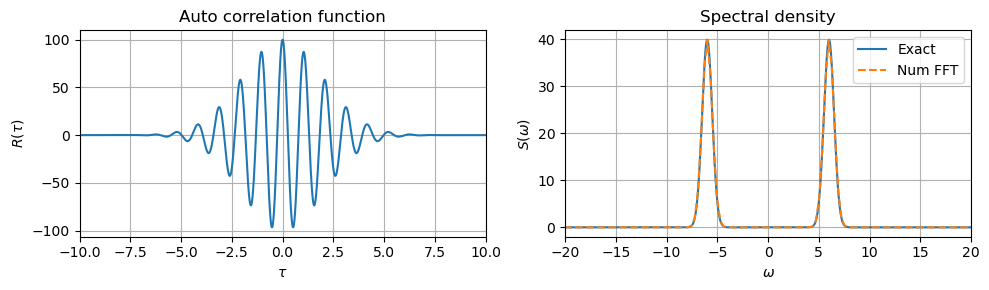

In [4]:

N=len(R) # Number of data points in time domain

S_fft = np.fft.fft(R)/N # DFT
f_fft = np.fft.fftfreq(N, d=(tau[1] - tau[0])) # Frequency axis in Hz

S_fft_shift = np.fft.fftshift(S_fft) # Shift elements in vector, goes from [-omega,...,0,...+omega]
f_fft_shift = np.fft.fftshift(f_fft)

S_fft_shift=S_fft_shift*np.exp(-1j*2*np.pi*f_fft_shift*tau[0]) # Compensate for time axis not starting at 0

S_fft_num=S_fft_shift*(N*dtau)/(2*np.pi) # Convert from a DFT to a continuous FT

omega_fft_shift=f_fft_shift*2*np.pi # Convert to rad/s

print(f'Maximum imaginary part: {np.max(np.abs(S_fft_num.imag)):.2e}')


# Plot ACF
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(tau, R, label='ACF')
axes[0].set_xlim(-10,10)
axes[0].set_xlabel(r'$\tau$')
axes[0].set_ylabel(r'$R(\tau)$')
axes[0].set_title('Auto correlation function')
axes[0].grid(True)

# Plot PSD
axes[1].plot(omega,S, label='Exact')
axes[1].plot(omega_fft_shift,np.real(S_fft_num), linestyle='--',label='Num FFT')
axes[1].set_xlim(-20,20)
axes[1].set_xlabel(r'$\omega$')
axes[1].set_ylabel(r'$S(\omega)$')
axes[1].set_title('Spectral density')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
